# non-causal LTI

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch import nn
from torch.nn import functional as F
from torch.fft import rfft, irfft
from einops import rearrange, einsum



In [2]:
from models import LTI

In [3]:
class Block(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.main = LTI(dim, dim, causal=False, mimo=True)
        self.gate = LTI(dim, dim, causal=False, mimo=True)
        self.sigma = nn.SiLU()

    def __call__(self, x):
        return x + self.main(x) * self.sigma(self.gate(x))


class NAGA(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 16,
        depth: int = 4,
        patch_size: int = 1,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.patch_embed = nn.Linear(input_dim * patch_size, hidden_dim)
        self.blocks = nn.Sequential(*(Block(hidden_dim) for _ in range(depth)))
        self.patch_unembed = nn.Linear(hidden_dim, input_dim * patch_size)

    def __call__(self, x):
        x = rearrange(x, "B (L P) D -> B L (P D)", P=self.patch_size)
        x = self.patch_embed(x)
        for block in self.blocks:
            x = block(x)
        x = self.patch_unembed(x)
        x = rearrange(x, "B L (P D) -> B (L P) D", P=self.patch_size)
        return x

In [4]:
from datasets import SpeechComand

device = torch.device("cuda:1")
dataset = SpeechComand()
dataloader = dataset.train_dataloader(batch_size=256)

model = NAGA(input_dim=1, depth=4).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

100%|██████████| 151/151 [01:51<00:00,  1.35it/s, loss=0.15] 


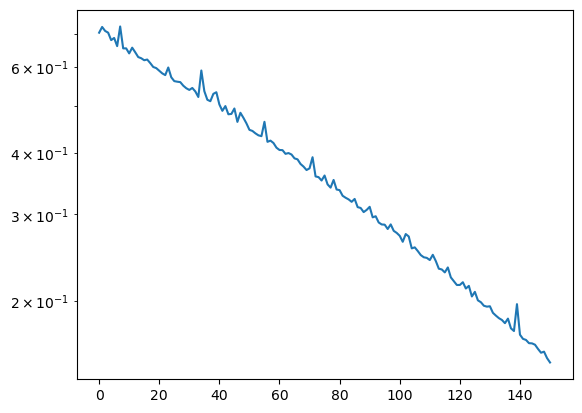

In [5]:
losses = []
for epoch in range(1):
    for x, y in (pbar := tqdm(dataloader)):
        x, y = x.to(device), y.to(device)
        loss = F.mse_loss(model(x), x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        pbar.set_postfix(loss=loss.item())
    break
plt.semilogy(losses)
plt.show()

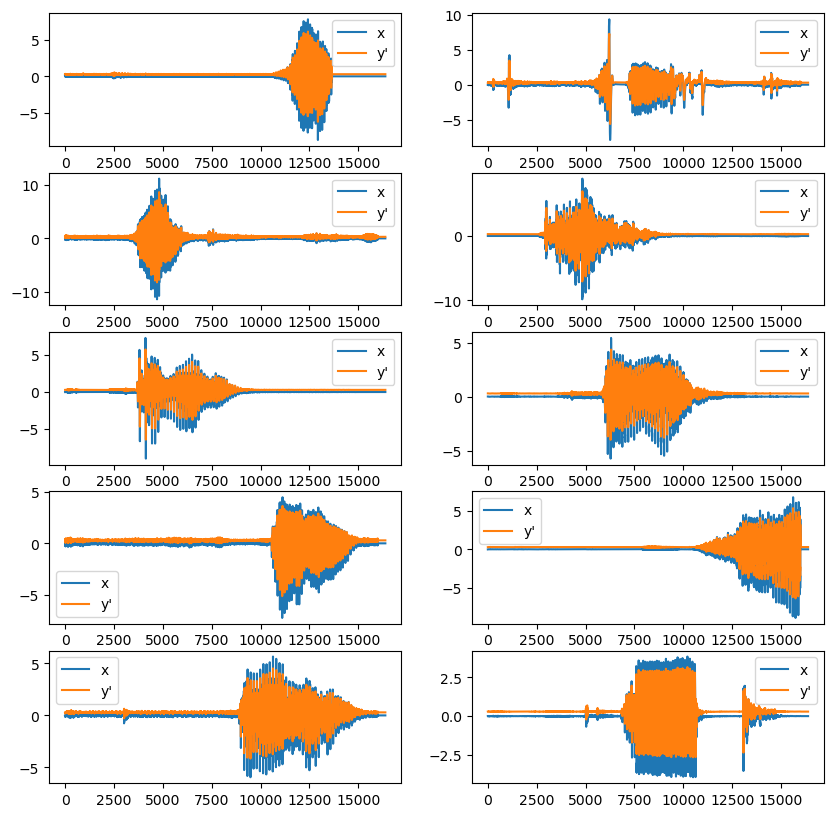

In [6]:
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(5, 2, 1+i)
    plt.plot(x[i, :, 0].cpu().numpy(), label="x")
    plt.plot(model(x)[i, :, 0].detach().cpu().numpy(), label="y'")
    plt.legend()
plt.show()